Forecasting Monthly Home Values by Zip Code Using Zillow Data
WGU Data Analytics Capstone
Task 3

Import Raw Data

We begin by importing Zillow's ZHVI dataset. This dataset Tracks Monthly home values by US ZIP Code.
This dataset forms the foundation of our forecasting model.

In [1]:
import pandas as pd

In [2]:
raw_path = "../data/raw/Zip_zhvi_uc_sfr_tier_0.33_0.67_sm_sa_month.csv"
df = pd.read_csv(raw_path)

Explore Dimensions

This shows the dataset size. Containing thousands of Zip codes and over 300 months of prices data by date. This enables robust temporal modeling.


In [3]:
print(df.shape)

(26208, 314)


In [4]:
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,2024-08-31,2024-09-30,2024-10-31,2024-11-30,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,215574.438255,...,510182.434440,510892.763641,512049.650147,512792.660486,513227.722201,513665.946230,513338.383882,512408.507833,510568.598127,508318.844450
1,61148,2,8701,zip,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,148477.755194,...,695796.402981,702604.063025,709293.474456,714159.727665,716847.338283,717878.902186,720826.783733,724843.289367,729957.745787,734632.468660
2,91940,3,77449,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,106161.586055,...,288461.727101,288271.118755,287847.183593,287044.229109,286301.877814,285680.843518,285044.264672,284194.128893,283214.282228,282393.931681
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,324297.207309,...,964100.578626,966858.639801,969170.155864,970457.410038,970540.504388,969886.051550,970434.250479,970851.001272,974994.605890,981018.751871
4,91733,5,77084,zip,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,105388.243306,...,282674.177502,282423.296576,281911.642124,281303.549642,280961.447460,280719.060835,280312.404076,279436.475212,278371.471330,277455.350725


To perform our time series analysis, the format needs to be transformed from wide to long. Allowing us to treat each row as a (ZIP, date, Price) record. 

In [5]:
id_vars = ['RegionID', 'RegionName', 'SizeRank', 'RegionType', 'StateName']
date_columns = df.columns.difference(id_vars)
#Melt to long format
df_melted = df.melt(id_vars, value_vars = date_columns,var_name='date', value_name='price')
#Convert to datetime
df_melted['date'] = pd.to_datetime(df_melted['date'], format='%Y-%m-%d', errors='coerce')
#drop rows with missing strings/values
df_melted.dropna(subset=['date', 'price'], inplace=True)
print(df_melted.head())

   RegionID  RegionName  SizeRank RegionType StateName       date  \
0     91982       77494         1        zip        TX 2000-01-31   
1     61148        8701         2        zip        NJ 2000-01-31   
2     91940       77449         3        zip        TX 2000-01-31   
3     62080       11368         4        zip        NY 2000-01-31   
4     91733       77084         5        zip        TX 2000-01-31   

           price  
0  215574.438255  
1  148477.755194  
2  106161.586055  
3  324297.207309  
4  105388.243306  


Reshaping and Cleaning

ZIP codes are also filtered to Colorado only as that is the region we are studying.

In [6]:
#Filter Colorado Zip by prefix (80000-81658)
df_melted['RegionName'] = df_melted['RegionName'].astype(str).str.zfill(5)

df_co = df_melted[df_melted['RegionName'].str.match(r'^80[0-9]{2}|^81[0-6][0-9]')]
print(df_co.head())

     RegionID RegionName  SizeRank RegionType StateName       date  \
165     93203      80013       171        zip        CO 2000-01-31   
186     93205      80015       192        zip        CO 2000-01-31   
231     93263      80134       237        zip        CO 2000-01-31   
328     93295      80219       335        zip        CO 2000-01-31   
473     93206      80016       484        zip        CO 2000-01-31   

             price  
165  160102.330274  
186  200965.581049  
231  240161.640851  
328  127038.557627  
473   310337.17967  


Save Cleaned Data

Colorado specific data is saved cutting down the original file size and focusing on our target region.

In [7]:
import os
os.makedirs('../data', exist_ok=True)
df_co.to_csv('../data/colorado_home_values.csv', index=False)

In [8]:
import pandas as pd
df_co = pd.read_csv('../data/processed/colorado_home_values.csv', parse_dates=["date"])

Examining a specific ZIP Code

To understand the process we will walk through a single ZIP code. This will help visualize the logic at a granular level.


In [9]:
#Selecting one ZIP
df_co['RegionName'] = df_co['RegionName'].astype(str).str.strip()
target_zip ='80132'
df_zip = df_co[df_co['RegionName'] == target_zip].sort_values('date').copy()
df_zip.head(25)

,RegionName,date,price
85,80132,2000-01-31,263928.496889
350,80132,2000-02-29,264394.339635
615,80132,2000-03-31,264818.011954
880,80132,2000-04-30,265764.611257
1145,80132,2000-05-31,266746.040697
1410,80132,2000-06-30,268115.751447
1675,80132,2000-07-31,270127.850858
1940,80132,2000-08-31,272398.769861
2205,80132,2000-09-30,274676.544687
2470,80132,2000-10-31,276814.092968


Lag Feature Engineering

Lag features capture price behavior over previous months. These features provide the temporal signal necessary for prediction.

In [10]:
#Create Lag features
for lag in range(1,4):
    df_zip[f'value_lag_{lag}'] = df_zip['price'].shift(lag)
df_zip.dropna(inplace=True)

Split data for training

We simulate real world forecasting by training on historical data and testing on the past 12 months, this preserves time order rather than a random split.

In [11]:
#Split into Train Test using last 12 months as test

train = df_zip[:-12]
test = df_zip[-12:]

feature_cols = [f'value_lag_{i}' for i in range(1,4)]
target_col = 'price'

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

Train Random Forest Model

We use Random Forest due to its ability to model non-linear trends and its robustness to outliers. Mean Absolute Error (MAE) is our evaluation metric.

In [12]:
#Train Model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f'Mean Absolute Error (Test): {mae:.2f}')

Mean Absolute Error (Test): 5465.07


Visualizing Predictions

The line plot shows how closely the model tracks actual values, dotted line are our predicted values. This is useful for model diagnostics and stakeholder insights.

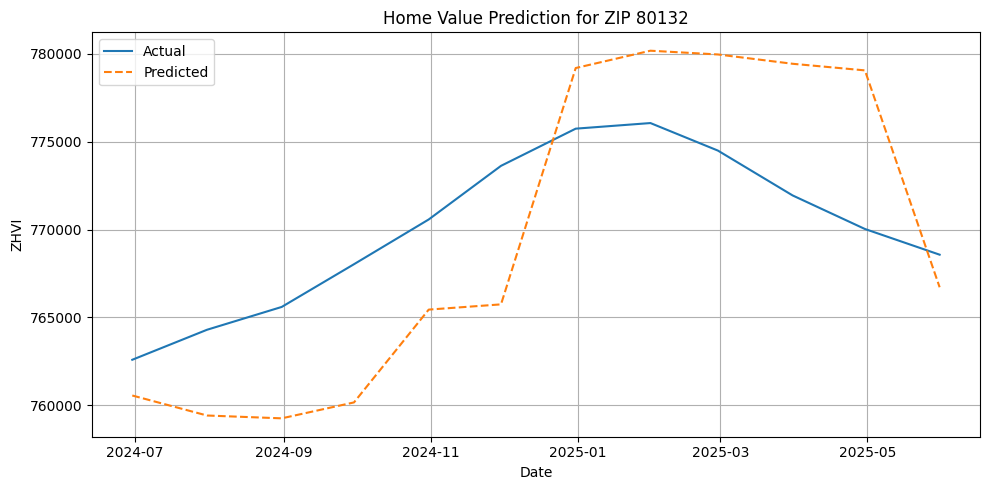

In [13]:
#Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(test['date'], y_test, label='Actual')
plt.plot(test['date'], y_pred, label='Predicted', linestyle='--')
plt.title(f'Home Value Prediction for ZIP {target_zip}')
plt.ylabel('ZHVI')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

XGBoost Modeling

XGBoost is another strong candidate for handling tabular data efficiently. We will compare the MAE values against the Random Forest outcome to evaluate the better model.

In [14]:
#Trying XGBoost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

#Prepare target
feature_cols = [f'value_lag_{i}' for i in range(1,4)]
X_train = df_zip[:-12][feature_cols]
y_train = df_zip[:-12]['price']
X_test = df_zip[-12:][feature_cols]
y_test = df_zip[-12:]['price']

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

#prediction and evaluation
y_pred = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f'XGBoost MAE: ${mae:,.0f}')

XGBoost MAE: $5,614


XGBoost Visualization

The chart below compares XGBoost forecast to the actual trend. This allows us to visually assess the model.

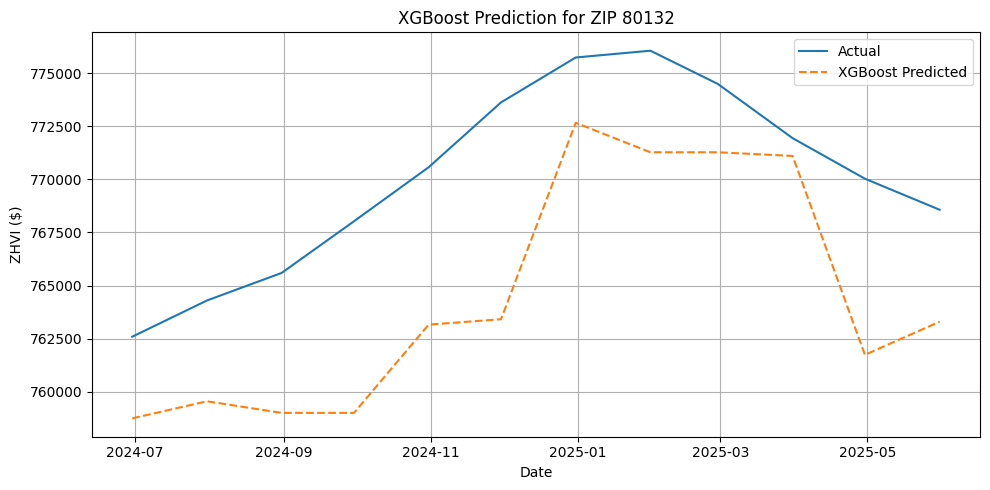

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(df_zip[-12:]["date"], y_test, label="Actual")
plt.plot(df_zip[-12:]["date"], y_pred, label="XGBoost Predicted", linestyle="--")
plt.title(f"XGBoost Prediction for ZIP {target_zip}")
plt.ylabel("ZHVI ($)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Foreward Looking Prediction

We use the model recursively to predict future values based on recent predictions. This enables a rolling six month forecast.

In [16]:
#forward looking prediction...

#last known values to seed prediction
last_known = df_zip[['date', 'price']].copy().sort_values('date')
last_known = last_known.iloc[-3:] #last three months

#create future dates
future_months = 6
last_date = last_known['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_months, freq='MS')

#store predictions
predictions = []

for date in future_dates:
    
    lags = last_known['price'].values[-3:]
    X_next = pd.DataFrame([{
        'value_lag_1': lags[-1], 
        'value_lag_2': lags[-2],
        'value_lag_3': lags[-3]
    }])
    
    y_next = model.predict(X_next)[0]
    predictions.append({'date': date, 'predicted_price': y_next})
    
    last_known = pd.concat([last_known, pd.DataFrame({'date': [date], 'price': [y_next]})], ignore_index=True)
    
df_forecast = pd.DataFrame(predictions)
print(df_forecast)

        date  predicted_price
0 2025-07-01    765617.711150
1 2025-08-01    760091.811072
2 2025-09-01    758823.569858
3 2025-10-01    758874.529230
4 2025-11-01    759317.037849
5 2025-12-01    759748.967633


Charting the Forecast

This chart overlays the historical and forecasted values, giving a full picture of the home price movement for the selected ZIP code. 

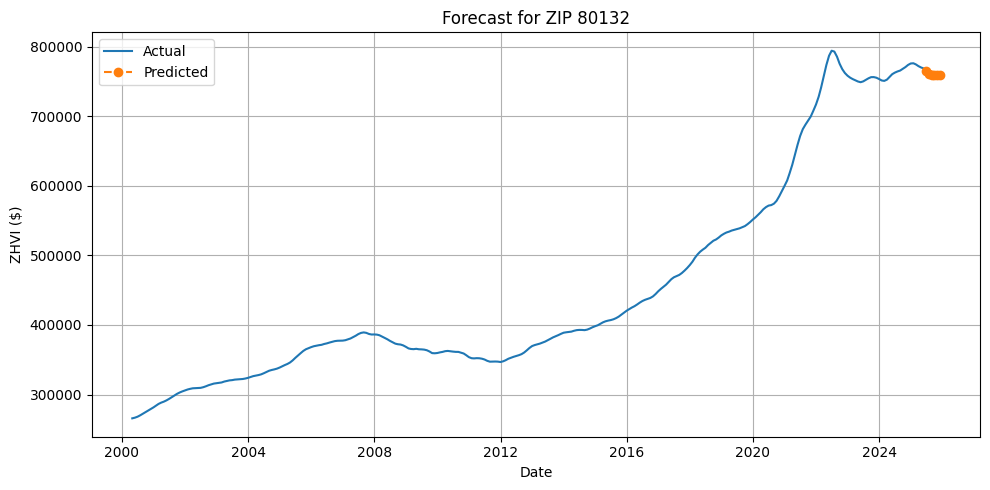

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(df_zip["date"], df_zip['price'], label="Actual")
plt.plot(df_forecast['date'], df_forecast['predicted_price'], label="Predicted", linestyle="--", marker='o')
plt.title(f"Forecast for ZIP {target_zip}")
plt.ylabel("ZHVI ($)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
#forward looking prediction...

#last known values to seed prediction
last_known = df_zip[['date', 'price']].copy().sort_values('date')
last_known = last_known.iloc[-3:] #last three months

#create future dates
future_months = 6
last_date = last_known['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_months, freq='MS')

#store predictions
predictions = []

for date in future_dates:
    
    lags = last_known['price'].values[-3:]
    X_next = pd.DataFrame([{
        'value_lag_1': lags[-1], 
        'value_lag_2': lags[-2],
        'value_lag_3': lags[-3]
    }])
    
    y_next = xgb_model.predict(X_next)[0]
    predictions.append({'date': date, 'predicted_price': y_next})
    
    last_known = pd.concat([last_known, pd.DataFrame({'date': [date], 'price': [y_next]})], ignore_index=True)
    
df_forecast_xgb = pd.DataFrame(predictions)
print(df_forecast_xgb)

        date  predicted_price
0 2025-07-01      763294.5000
1 2025-08-01      758907.6875
2 2025-09-01      755808.1250
3 2025-10-01      753218.8125
4 2025-11-01      751491.8125
5 2025-12-01      750179.6250


Creating a Module

Here we start create the module to hold the forecasting logic for reuse in the app.

In [19]:
from forecast_model import forecast_home_values

ModuleNotFoundError: No module named 'forecast_model'

In [ ]:
history, forecast = forecast_home_values(df_co, target_zip='80132', )

Loop Through ZIP
Here we evaluate the accuracy of the model across all the ZIP codes in Colorado. This step helps locate the strong and weak performing ZIP codes.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

#Load cleaned dataset
df_co = pd.read_csv('../data/colorado_home_values.csv', parse_dates=['date'])

#Ensure ZIP are 5 digit strings
df_co['RegionName'] = df_co['RegionName'].astype(str).str.zfill(5)

#Create empty list
results = []

#Loop through ZIP

for zip_code in df_co['RegionName'].unique():
   df_zip = df_co[df_co['RegionName'] == zip_code].sort_values('date').copy()

   #Create lag features
   for lag in range(1,4):
       df_zip[f'value_lag{lag}'] = df_zip['price'].shift(lag)
       df_zip.dropna(inplace=True)

   #Skip Zips with little data
   if len(df_zip) < 20:
       continue
   #Train/Test split: last 12 months
   train = df_zip[:12]
   test = df_zip[-12:]

   feature_cols = [f'value_lag{lag}' for i in range(1,4)]
   X_train, y_train = train[feature_cols], train['price']
   X_test, y_test = test[feature_cols], test['price']

   if X_test.isnull().values.any() or X_train.empty:
       continue

   #Train model
   model = RandomForestRegressor(random_state=42)
   mae = mean_absolute_error(y_test, y_pred)

   results.append({'ZIP':zip_code, 'MAE': mae})

mae_df = pd.DataFrame(results).sort_values(by='MAE', ascending=True)
print(mae_df.head())


Create Heat Map
The next few cells merge the zip code data to the latitude and longitude centroids. Preparing the project for spacial visualization/heatmap.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

#Load cleaned dataset
df_co = pd.read_csv('../data/colorado_home_values.csv', parse_dates=['date'])

#Ensure ZIP are 5 digit strings
df_co['RegionName'] = df_co['RegionName'].astype(str).str.zfill(5)

#Create empty list
results = []

#Loop through ZIP
for zip_code in df_co['RegionName'].unique():
   df_zip = df_co[df_co['RegionName'] == zip_code].sort_values('date').copy()

   #Create lag features
   for lag in range(1,4):
       df_zip[f'value_lag{lag}'] = df_zip['price'].shift(lag)
       df_zip.dropna(inplace=True)

   #Skip Zips with little data
   if len(df_zip) < 20:
       continue
   #Train/Test split: last 12 months
   train = df_zip[:-12]
   test = df_zip[-12:]

   feature_cols = [f'value_lag{lag}' for i in range(1,4)]
   X_train, y_train = train[feature_cols], train['price']
   X_test, y_test = test[feature_cols], test['price']

   if X_test.isnull().values.any() or X_train.empty:
       continue

   #Train model
   model = RandomForestRegressor(random_state=42)
   mae = mean_absolute_error(y_test, y_pred)

   results.append({'ZIP': zip_code, 'MAE': mae})

mae_df = pd.DataFrame(results).sort_values(by='MAE', ascending=False)
print(mae_df.head())

#Load Zip code Lat Long information for streamlit
df_geo = pd.read_csv("../data/external/us_zip_centroids.csv", dtype={"Zip Code Tabulation Area Code": str})

df_geo.columns = df_geo.columns.str.strip()
#Rename Relevant columns
df_geo = df_geo.rename(columns={
    "Zip Code Tabulation Area Code":"RegionName",
    "Internal Point Latitude": "lat",
    "Internal Point Longitude": "lng"
})

#Filter to Colorado Zips
df_geo = df_geo[df_geo["RegionName"].str.startswith(("80", "81"))] 

print(df_geo.head())

In [ ]:
#All Zip Codes are 5 characters
mae_df['RegionName'] = mae_df['ZIP'].astype(str).str.zfill(5)
#Merge data
mae_geo = pd.merge(mae_df, df_geo[['RegionName', 'lat', 'lng']], on='RegionName', how='inner')
print(mae_geo.head())

In [ ]:
mae_df['MAE_str'] = mae_df['MAE'].apply(lambda x: f"${x:,.0f}")
mean_mae = mae_df['MAE'].mean()
print(mean_mae)
print(f"{zip_code}: MAE = ${mae:,.0f}\n Max Price = ${df_zip['price'].max():,.0f}\n Min Price = ${df_zip['price'].min():,.0f}")